<a href="https://colab.research.google.com/github/Kaynan1101/AtvEletivaI/blob/main/processing_tracking_player.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sun Mar  1 14:44:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   32C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics roboflow supervision opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 148.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [3]:
!pip install roboflow

In [4]:
from google.colab import userdata
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("francisco-workspace").project("hockey-3fz5i")
version = project.version(7)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to hockey-7 in yolov8:: 100%|██████████| 7034/7034 [00:00<00:00, 8088.45it/s] 


In [6]:
model = YOLO("yolov8s.pt")

model.train(
    data="/content/hockey-7/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    cache=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hockey-7/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a34aee02480>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [15]:
from tqdm import tqdm
import supervision as sv
PLAYER_DETECTION_MODEL = YOLO("yolov8s.pt")

SOURCE_VIDEO_PATH = "/content/video1.avi"
PLAYER_ID = 0
STRIDE = 30

frame_generator = sv.get_video_frames_generator(
    source_path=SOURCE_VIDEO_PATH, stride=STRIDE)

crops = []
for frame in tqdm(frame_generator, desc='collecting crops'):
    result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3)[0]
    detections = sv.Detections.from_ultralytics(result)
    detections = detections.with_nms(threshold=0.5, class_agnostic=True)
    detections = detections[detections.class_id == PLAYER_ID]
    players_crops = [sv.crop_image(frame, xyxy) for xyxy in detections.xyxy]
    crops += players_crops

collecting crops: 0it [00:00, ?it/s]


0: 384x640 12 persons, 9.1ms
Speed: 2.2ms preprocess, 9.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


collecting crops: 1it [00:00,  7.15it/s]


0: 384x640 12 persons, 7.7ms
Speed: 2.7ms preprocess, 7.7ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


collecting crops: 2it [00:00,  5.46it/s]

...

collecting crops: 70it [00:13,  5.13it/s]


0: 384x640 11 persons, 2 skateboards, 7.5ms
Speed: 2.7ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


collecting crops: 71it [00:13,  5.23it/s]


0: 384x640 11 persons, 7.5ms
Speed: 2.3ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


collecting crops: 72it [00:13,  5.25it/s]


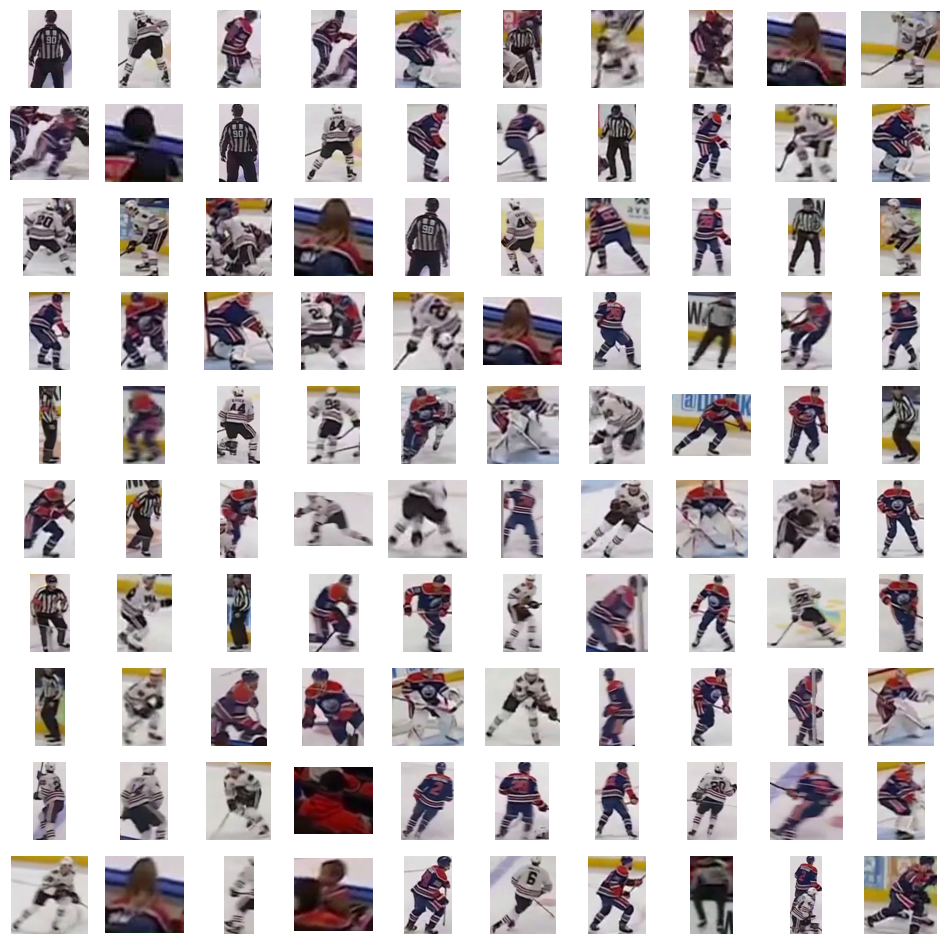

In [16]:
sv.plot_images_grid(crops[:100], grid_size=(10, 10))

In [18]:
import numpy as np
from sklearn.cluster import KMeans

def get_dominant_color(image):
    # Placeholder function for extracting dominant color
    # You need to implement this based on your specific needs.
    # For example, you could resize the image and then apply KMeans
    # to the pixel values to find the dominant color.
    # For now, let's return a dummy color (e.g., mean color)
    if image.size == 0:
        return np.array([0, 0, 0])
    # Reshape the image to a list of pixels
    pixels = image.reshape(-1, 3)
    # Use KMeans to find the dominant color
    # Reduced n_init to avoid warning in older sklearn versions
    kmeans_model = KMeans(n_clusters=1, n_init=10, random_state=0)
    kmeans_model.fit(pixels)
    return kmeans_model.cluster_centers_[0]

class TeamClassifier:
    def __init__(self, n_teams=2):
        self.kmeans = KMeans(n_clusters=n_teams, n_init=10, random_state=0)
        self.fitted = False

    def fit(self, crops):
        colors = np.array([get_dominant_color(c) for c in crops])
        self.kmeans.fit(colors)
        self.fitted = True

    def predict(self, crops):
        colors = np.array([get_dominant_color(c) for c in crops])
        return self.kmeans.predict(colors)

team_classifier = TeamClassifier()
team_classifier.fit(crops)

In [19]:
def resolve_goalkeepers_team_id(players_detections, goalkeepers_detections):
    goalkeepers_xy = goalkeepers_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    players_xy = players_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)

    team_ids = []
    for gk_xy in goalkeepers_xy:
        distances = {}
        for team_id in [0, 1]:
            team_mask = players_detections.class_id == team_id
            if team_mask.sum() == 0:
                distances[team_id] = float('inf')
                continue
            team_xy = players_xy[team_mask]
            dist = np.linalg.norm(team_xy - gk_xy, axis=1).mean()
            distances[team_id] = dist
        team_ids.append(min(distances, key=distances.get))

    return np.array(team_ids)


0: 384x640 12 persons, 9.7ms
Speed: 2.9ms preprocess, 9.7ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


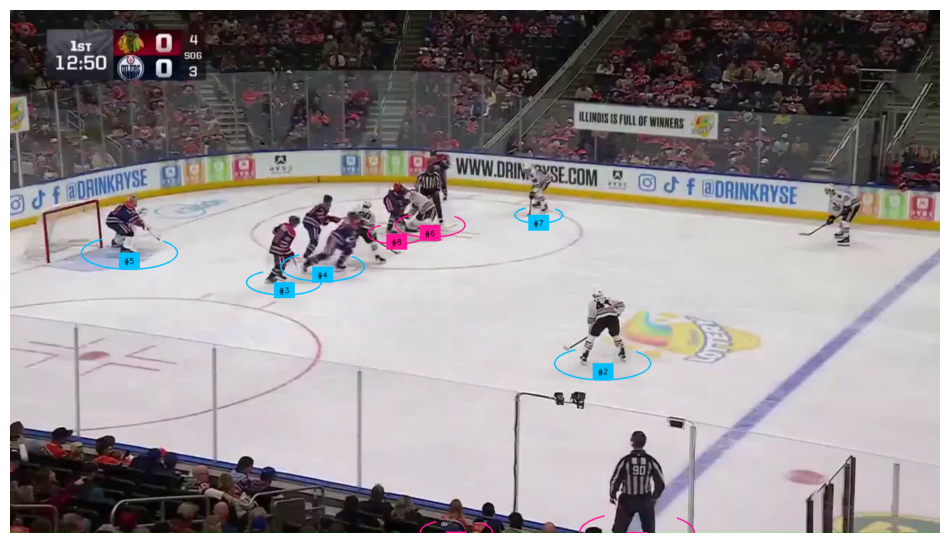

In [20]:
import supervision as sv

SOURCE_VIDEO_PATH = "/content/video1.avi"
GOALKEEPER_ID = 1  # confirme qual ID seu modelo usa
PLAYER_ID = 0      # confirme no seu modelo

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)

tracker = sv.ByteTrack()
tracker.reset()

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# Usando predict (YOLO local) em vez de infer (Roboflow API)
result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3)[0]
detections = sv.Detections.from_ultralytics(result)

all_detections = detections.with_nms(threshold=0.5, class_agnostic=True)
all_detections = tracker.update_with_detections(detections=all_detections)

goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
players_detections = all_detections[all_detections.class_id == PLAYER_ID]

# Classifica time dos jogadores com K-Means
players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
players_detections.class_id = team_classifier.predict(players_crops)

# Goleiros: resolve qual time pertence
goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
    players_detections, goalkeepers_detections)

all_detections = sv.Detections.merge([players_detections, goalkeepers_detections])

labels = [f"#{tid}" for tid in all_detections.tracker_id]
all_detections.class_id = all_detections.class_id.astype(int)

annotated_frame = frame.copy()
annotated_frame = ellipse_annotator.annotate(scene=annotated_frame, detections=all_detections)
annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=all_detections, labels=labels)

sv.plot_image(annotated_frame)

In [ ]:
import supervision as sv
import numpy as np

SOURCE_VIDEO_PATH = "/content/video1.avi"
TARGET_VIDEO_PATH = "/content/output.avi"

GOALKEEPER_ID = 1
PLAYER_ID = 0

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)

tracker = sv.ByteTrack()
tracker.reset()

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame in tqdm(frame_generator, total=video_info.total_frames, desc="Processando vídeo"):

        result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3)[0]
        detections = sv.Detections.from_ultralytics(result)

        all_detections = detections.with_nms(threshold=0.5, class_agnostic=True)
        all_detections = tracker.update_with_detections(detections=all_detections)

        goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
        players_detections = all_detections[all_detections.class_id == PLAYER_ID]

        # Classifica times
        if len(players_detections) > 0:
            players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
            players_detections.class_id = team_classifier.predict(players_crops)

        # Resolve goleiros
        if len(goalkeepers_detections) > 0 and len(players_detections) > 0:
            goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
                players_detections, goalkeepers_detections)
        elif len(goalkeepers_detections) > 0:
            goalkeepers_detections.class_id = np.array([0] * len(goalkeepers_detections))

        all_detections = sv.Detections.merge([players_detections, goalkeepers_detections])

        labels = [f"#{tid}" for tid in all_detections.tracker_id]
        all_detections.class_id = all_detections.class_id.astype(int)

        annotated_frame = frame.copy()
        annotated_frame = ellipse_annotator.annotate(scene=annotated_frame, detections=all_detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=all_detections, labels=labels)

        sink.write_frame(annotated_frame)

print("Vídeo salvo em:", TARGET_VIDEO_PATH)

Processando vídeo:   0%|          | 0/2137 [00:00<?, ?it/s]


0: 384x640 12 persons, 8.9ms
Speed: 2.6ms preprocess, 8.9ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


Processando vídeo:   0%|          | 1/2137 [00:00<08:48,  4.04it/s]


0: 384x640 12 persons, 1 skateboard, 8.8ms
Speed: 3.4ms preprocess, 8.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


Processando vídeo:   0%|          | 2/2137 [00:00<09:12,  3.87it/s]

...


0: 384x640 10 persons, 1 skateboard, 8.9ms
Speed: 3.3ms preprocess, 8.9ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


Processando vídeo:  42%|████▏     | 908/2137 [05:17<08:27,  2.42it/s]


0: 384x640 10 persons, 19.1ms
Speed: 3.3ms preprocess, 19.1ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


Processando vídeo:  43%|████▎     | 909/2137 [05:17<09:11,  2.23it/s]


0: 384x640 11 persons, 18.2ms
Speed: 6.3ms preprocess, 18.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
model = YOLO("runs/detect/train/weights/best.pt")
model.track("/content/test/video.mp4", classes=[0, 1], conf=0.3, persist=True, save=True)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 170ms
Prepared 1 package in 55ms
Installed 1 package in 3ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2137) /content/test/video.mp4: 384x640 2 goalkeepers, 6 players, 9.5ms
video 1/1 (